In [1]:
#importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


In [4]:
#loading dataset 
df = pd.read_csv("Data_file - data_file.csv")   
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [5]:
#basic information 
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
#size
df.shape

(20640, 10)

In [8]:
#check miss value 
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
#handling missing values if there is any and if in the numerical form , replace with median 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [10]:
#for categorical , replace with the mode 
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


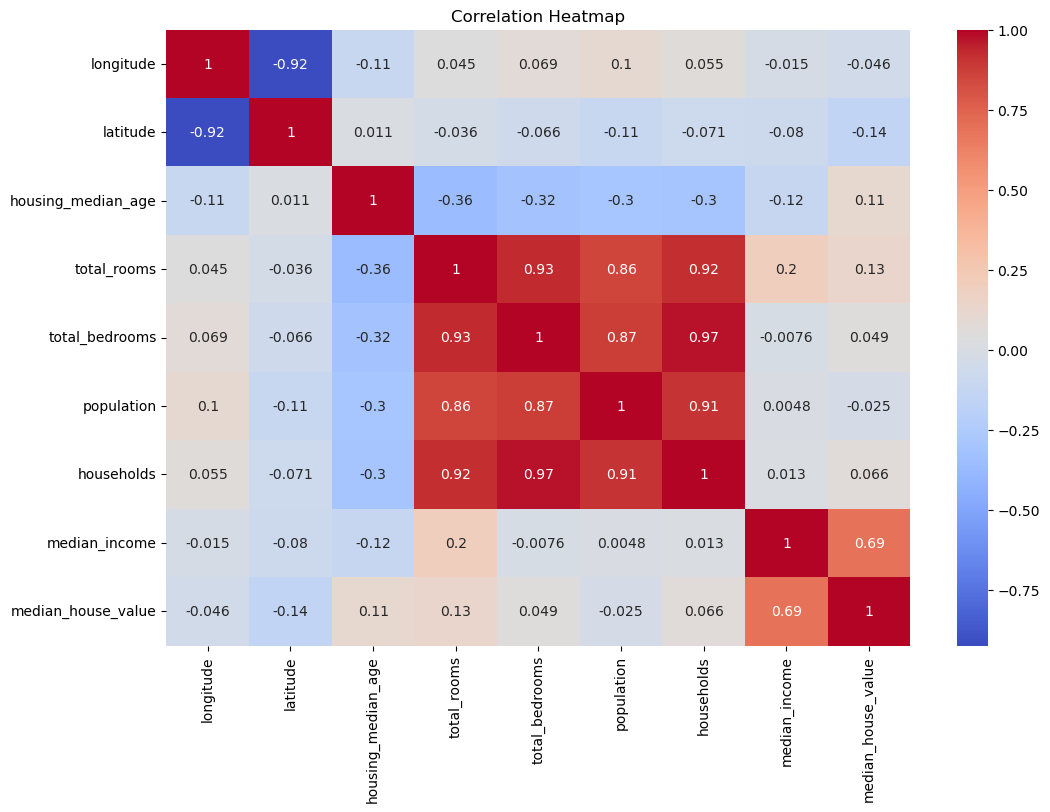

In [12]:
#Exploratory Data Analysis (EDA)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


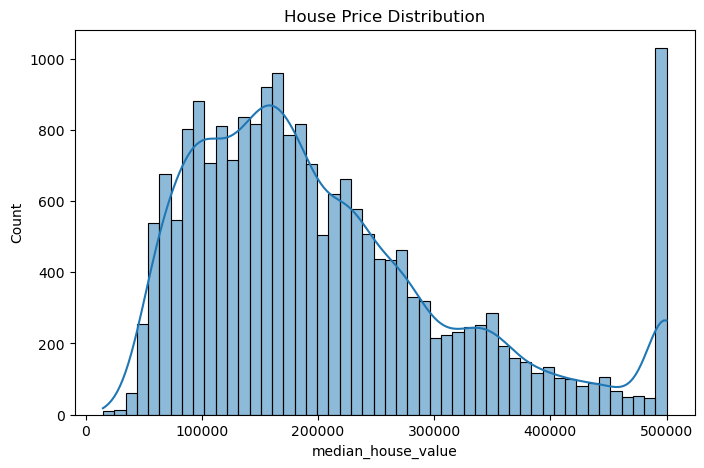

In [15]:
# for target Variable Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("House Price Distribution")
plt.show()


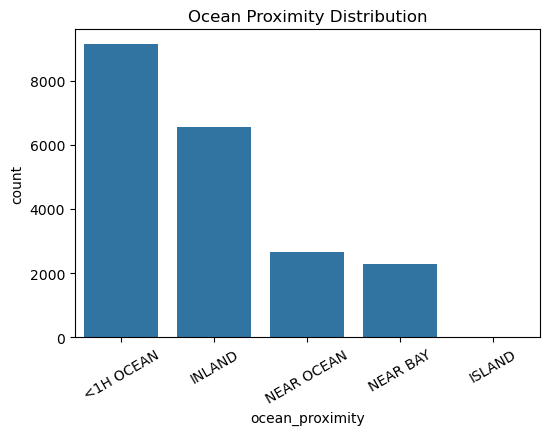

In [16]:
#Ocean Proximity Countplot
plt.figure(figsize=(6,4))
sns.countplot(x="ocean_proximity", data=df,
              order=df["ocean_proximity"].value_counts().index)
plt.xticks(rotation=30)
plt.title("Ocean Proximity Distribution")
plt.show()


In [17]:
#Encode Categorical Data
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)


In [20]:
#Feature & Target Selection
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]


In [27]:
#Train Test Split
X_train, X_test,y_train,y_test =train_test_split(
    X,y,test_size=0.2,random_state=42)


X_train.shape, X_test.shape


((16512, 12), (4128, 12))

In [28]:
#SIMPLE LINEAR REGRESSION
X_simple = df[["median_income"]]
y_simple = df["median_house_value"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(Xs_train, ys_train)

ys_pred = simple_model.predict(Xs_test)


In [29]:
#Evaluation
mse_simple = mean_squared_error(ys_test, ys_pred)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(ys_test, ys_pred)

print("Simple Linear Regression Results")
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R² Score:", r2_simple)


Simple Linear Regression Results
MSE: 7091157771.76555
RMSE: 84209.01241414454
R² Score: 0.45885918903846656


In [30]:
#MULTIPLE LINEAR REGRESSION
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred = multi_model.predict(X_test)


In [31]:
#Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


Multiple Linear Regression Results
MSE: 4908476721.156615
RMSE: 70060.52184473518
R² Score: 0.6254240620553606


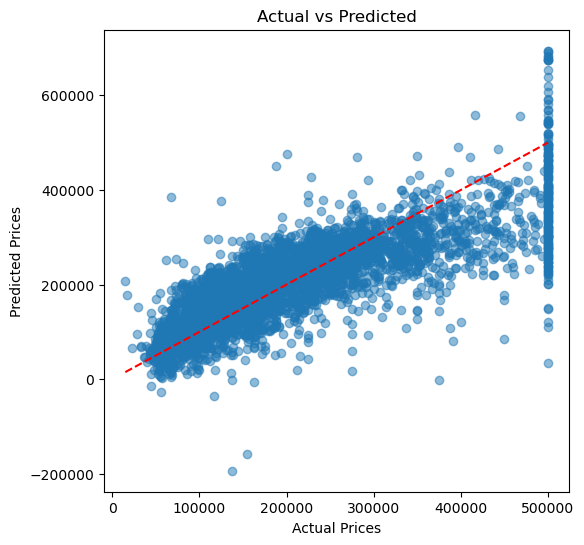

In [33]:
#Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [35]:
# Create new input as dictionary
new_house = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41,
    'total_rooms': 880,
    'total_bedrooms': 129,
    'population': 322,
    'households': 126,
    'median_income': 8.3252,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
    'ocean_proximity_NEAR OCEAN': 0
}

new_df = pd.DataFrame([new_house])

prediction = multi_model.predict(new_df)

print("Predicted House Price = $", round(prediction[0], 2))


Predicted House Price = $ 410584.36
